### Transfer Learning
##### Transfer Learning is a Machine Learning technique that allows to reutilize an already trained convolutional neural network (CNN) on a specific dataset and adapt it, or transfer it, to a different dataset. The reason you want to reuse a trained CNN is because it typically takes a long time to train. For example, training ResNet18 for 30 epochs in 4 NVIDIA K80 GPU took us 3 days. Training ResNet152 for 120 epochs in 4 NVIDIA K80 GPUs takes 4 months.



In [19]:
!pip install torchnet

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\sushm\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [20]:
import sys
import os
import numpy as np
import pandas as pd
from collections import Counter
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import lr_scheduler, SGD
from torch.autograd import Variable
from torchvision import models
from utils import (get_gpu_name, get_number_processors, plot_pytorch_data_stream, train_model, create_dataset, 
                   available_models, plot_metrics)



In [21]:
print("OS: ", sys.platform)
print("Python: ", sys.version)
print("PyTorch: ", torch.__version__)
print("Numpy: ", np.__version__)
print("Number of CPU processors: ", get_number_processors())
print("GPU: ", get_gpu_name())

OS:  win32
Python:  3.13.14 (tags/v3.13.14:fd17997, Jun 10 2026, 13:03:48) [MSC v.1944 64 bit (AMD64)]
PyTorch:  2.14.0+cpu
Numpy:  2.5.3
Number of CPU processors:  8
[WinError 2] The system cannot find the file specified
GPU:  None


In [22]:
model_names = available_models()
print(model_names)

['alexnet', 'convnext_base', 'convnext_large', 'convnext_small', 'convnext_tiny', 'densenet121', 'densenet161', 'densenet169', 'densenet201', 'efficientnet_b0', 'efficientnet_b1', 'efficientnet_b2', 'efficientnet_b3', 'efficientnet_b4', 'efficientnet_b5', 'efficientnet_b6', 'efficientnet_b7', 'efficientnet_v2_l', 'efficientnet_v2_m', 'efficientnet_v2_s', 'get_model', 'get_model_builder', 'get_model_weights', 'get_weight', 'googlenet', 'inception_v3', 'list_models', 'maxvit_t', 'mnasnet0_5', 'mnasnet0_75', 'mnasnet1_0', 'mnasnet1_3', 'mobilenet_v2', 'mobilenet_v3_large', 'mobilenet_v3_small', 'regnet_x_16gf', 'regnet_x_1_6gf', 'regnet_x_32gf', 'regnet_x_3_2gf', 'regnet_x_400mf', 'regnet_x_800mf', 'regnet_x_8gf', 'regnet_y_128gf', 'regnet_y_16gf', 'regnet_y_1_6gf', 'regnet_y_32gf', 'regnet_y_3_2gf', 'regnet_y_400mf', 'regnet_y_800mf', 'regnet_y_8gf', 'resnet101', 'resnet152', 'resnet18', 'resnet34', 'resnet50', 'resnext101_32x8d', 'resnext101_64x4d', 'resnext50_32x4d', 'shufflenet_v2_x0_

In [23]:
def finetune(dataloaders, model_name, sets, num_epochs, num_gpus, lr, momentum, lr_step, lr_epochs, verbose=True):
    #Class adaptation
    num_class = len(dataloaders[sets[0]].dataset.class_to_idx)
    model_ft = models.__dict__[model_name](pretrained=True)
    num_ftrs = model_ft.fc.in_features
    model_ft.fc = nn.Linear(num_ftrs, num_class)
    
    #gpus
    if num_gpus > 1: 
        model_ft = nn.DataParallel(model_ft)
    model_ft = model_ft.cuda()
    
    #loss
    criterion = nn.CrossEntropyLoss()

    # All parameters are being optimized
    optimizer = SGD(model_ft.parameters(), lr=lr, momentum=momentum)

    # Decay LR by a factor of lr_step every lr_epochs epochs
    exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=lr_epochs, gamma=lr_step)
    model_ft = train_model(dataloaders, model_ft, sets, criterion, optimizer, exp_lr_scheduler, 
                           num_epochs=num_epochs, verbose=verbose)
    return model_ft

#### Feature extraion

In [24]:
def freeze_and_train(dataloader, model_name, sets, num_epochs,num_gpus,lr, momentum, lr_step, lr_epochs, verbose = True):
    num_class = len(dataloader[sets[0]].dataset.class_to_idx)
    model_conv = models.__dict__[model_name](pretrained = True)
    for param in model_conv.parameters():
        param.requires_grad = False
    num_ftrs = model_conv.fc.in_features
    model_conv.fc = nn.Linear(num_ftrs, num_class)
    if num_gpus > 1: 
        model_conv = nn.DataParallel(model_conv)
    model_conv = model_conv.cuda()
    criterion = nn.CrossEntropyLoss()
    if num_gpus > 1:
        params = model_conv.module.fc.parameters()
    else:
        params = model_conv.fc.parameters()
    optimizer = SGD(params, lr=lr, momentum=momentum)
    # Decay LR by a factor of lr_step every lr_epochs epochs
    exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=lr_epochs, gamma=lr_step)
    model_conv = train_model(dataloaders, model_conv, sets, criterion, optimizer, exp_lr_scheduler, 
                             num_epochs=num_epochs, verbose=verbose)
    return model_conv

In [25]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\sushm\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [26]:
import kagglehub

In [27]:
# Download latest version
path = kagglehub.dataset_download("thedatasith/hymenoptera")

In [28]:
HYMENOPTERA_ROOT = path

In [36]:
HYMENOPTERA_ROOT = os.path.join(path, 'hymenoptera')

In [ ]:
#converting images into gray
HYMENOPTERA_GRAY_ROOT = os.path.join(,'hymenoptera_gray')


In [38]:
MODEL_NAME = 'resnet18'
BATCH_SIZE = 64
SETS = ['train','val']
NUM_GPUS = 4
EPOCHS = 15
LR = 0.001
LR_STEP = 0.1
LR_EPOCHS = 10
MOMENTUM = 0.9

In [39]:
os.listdir(HYMENOPTERA_ROOT)

['train', 'val']

In [40]:
print(HYMENOPTERA_ROOT)

C:\Users\sushm\.cache\kagglehub\datasets\thedatasith\hymenoptera\versions\5\hymenoptera


In [42]:
data_hymenoptera = create_dataset(HYMENOPTERA_ROOT, batch_size = BATCH_SIZE)
print(data_hymenoptera)

{'train': <torch.utils.data.dataloader.DataLoader object at 0x00000158E45D9090>, 'val': <torch.utils.data.dataloader.DataLoader object at 0x00000158E44C4D60>}


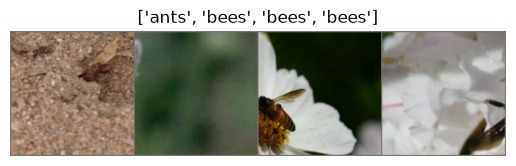

In [43]:
plot_pytorch_data_stream(data_hymenoptera['train'], max_images = 4)

#### Training

In [46]:
val_acc_ft = "validation accuracy using finetuning"
val_acc_fr = "validation accuracy using freezing"

In [47]:
df = pd.DataFrame(columns = [val_acc_ft, val_acc_fr])

#### Hymenoptera dataset

In [ ]:
model, metrics = finetune(data_hymenoptera,MODEL_NAME, SETS, EPOCHS, 1, LR, MOMENTUM, LR_STEP, LR_EPOCHS, verbose = False)

In [ ]:
dataset_name = "Dataset Hymenoptera"
plot_metrics(metrics, dataset_name + "(finetuning)")
df.at[dataset_name,val_acc_ft] = max(metrics['val_acc'])

In [ ]:
model, metrics = freeze_and_train(data_hymenoptera, MODEL_NAME, SETS, EPOCHS, 1, LR, 
                                  MOMENTUM, LR_STEP, LR_EPOCHS, verbose=False)

In [ ]:
plot_metrics(metrics, dataset_name + " (freeze and train)")
df.at[dataset_name, val_acc_fr] = max(metrics['val_acc'])